Successfully loaded 78 task records.

=== SANTA++ Accuracy by Probe Query Count ===
 probe_queries  avg_accuracy       std
            16     69.217692 31.892244
            32     75.243846 26.682182
            64     70.486923 29.823099
           128     78.410000 25.248141
           256     76.128462 24.017067

Baseline SDPA Overall Accuracy: 87.99%



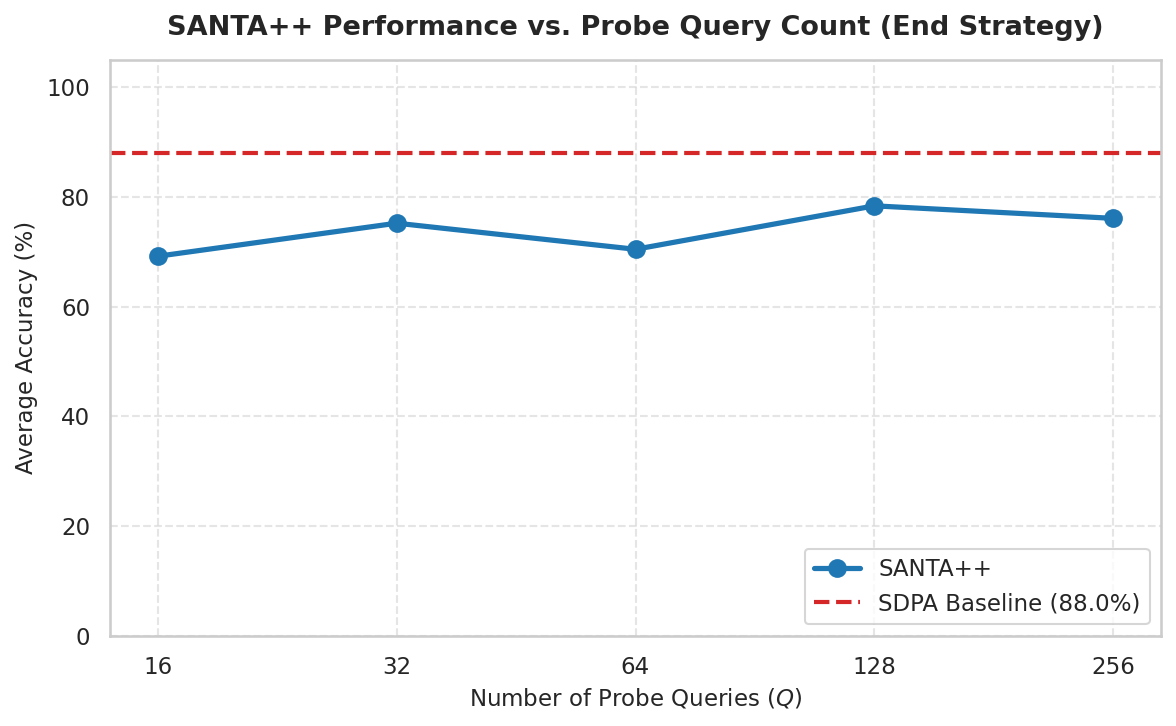

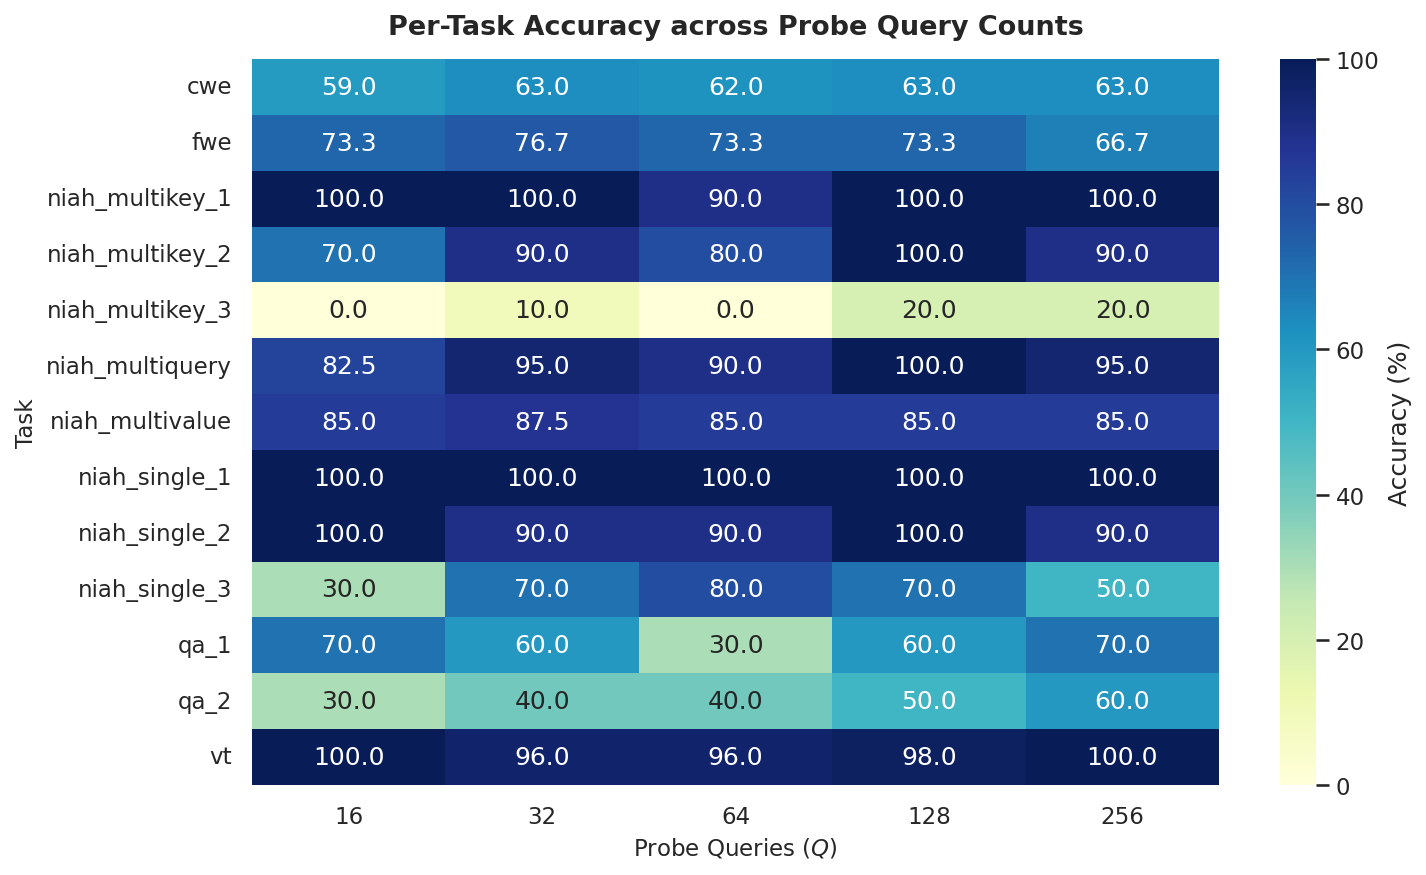

In [8]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 150

# ==============================================================================
# 1. Parse Results Directory
# ==============================================================================
RESULTS_DIR = Path("./full-probe-count-resweep")

records = []

for run_dir in sorted(RESULTS_DIR.glob("probe_q_*")):
    if not run_dir.is_dir():
        continue
    
    # Extract Q from probe_q_X folder name
    try:
        probe_q = int(run_dir.name.split("_")[-1])
    except ValueError:
        continue

    summary_file = run_dir / "summary.json"
    
    if summary_file.exists():
        try:
            with open(summary_file, "r", encoding="utf-8") as f:
                summary_data = json.load(f)
            
            # Key change: Navigating the top-level "backends" structure
            backends_dict = summary_data.get("backends", summary_data)
            
            for backend, backend_info in backends_dict.items():
                if not isinstance(backend_info, dict):
                    continue
                
                tasks_dict = backend_info.get("tasks", {})
                for task_name, task_metrics in tasks_dict.items():
                    # Skip aggregate summaries
                    if task_name in ["__selected_task_mean__", "aggregate"]:
                        continue
                    
                    if isinstance(task_metrics, dict) and "score" in task_metrics:
                        records.append({
                            "probe_queries": probe_q,
                            "backend": backend,
                            "task": task_name,
                            "accuracy": float(task_metrics["score"])
                        })
        except Exception as e:
            print(f"Error parsing {summary_file}: {e}")

df = pd.DataFrame(records)
print(f"Successfully loaded {len(df)} task records.\n")

if df.empty:
    raise RuntimeError(f"No records parsed from {RESULTS_DIR.resolve()}. Check folder path or contents.")

# ==============================================================================
# 2. Compute Aggregated Metrics
# ==============================================================================
# Extract baseline SDPA performance (evaluated on the first step)
sdpa_df = df[df["backend"] == "sdpa"]
sdpa_overall_acc = sdpa_df["accuracy"].mean() if not sdpa_df.empty else None

# Aggregate SANTA++ by probe_queries
santapp_df = df[df["backend"] == "santapp"]
summary_df = santapp_df.groupby("probe_queries")["accuracy"].agg(["mean", "std"]).reset_index()
summary_df.rename(columns={"mean": "avg_accuracy"}, inplace=True)

print("=== SANTA++ Accuracy by Probe Query Count ===")
print(summary_df.to_string(index=False))

if sdpa_overall_acc is not None:
    print(f"\nBaseline SDPA Overall Accuracy: {sdpa_overall_acc:.2f}%\n")

# ==============================================================================
# 3. Plot 1: Overall Accuracy vs. Probe Query Count
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 5))

ax.plot(
    summary_df["probe_queries"],
    summary_df["avg_accuracy"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#1f77b4",
    label="SANTA++"
)

if sdpa_overall_acc is not None:
    ax.axhline(
        y=sdpa_overall_acc,
        color="#d62728",
        linestyle="--",
        linewidth=2,
        label=f"SDPA Baseline ({sdpa_overall_acc:.1f}%)"
    )

ax.set_xscale("log", base=2)
ax.set_xticks(summary_df["probe_queries"])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax.set_title("SANTA++ Performance vs. Probe Query Count (End Strategy)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Number of Probe Queries ($Q$)", fontsize=11)
ax.set_ylabel("Average Accuracy (%)", fontsize=11)
ax.set_ylim(0, 105)
ax.legend(frameon=True, loc="lower right")
ax.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("probe_count_vs_accuracy_v2.png", dpi=300)
plt.show()

# ==============================================================================
# 4. Plot 2: Per-Task Breakdown Heatmap
# ==============================================================================
if not santapp_df.empty:
    pivot_df = santapp_df.pivot_table(
        index="task", 
        columns="probe_queries", 
        values="accuracy", 
        aggfunc="mean"
    )

    fig, ax = plt.subplots(figsize=(10, max(6, len(pivot_df) * 0.4)))
    sns.heatmap(
        pivot_df, 
        annot=True, 
        fmt=".1f", 
        cmap="YlGnBu", 
        cbar_kws={"label": "Accuracy (%)"},
        ax=ax
    )

    ax.set_title("Per-Task Accuracy across Probe Query Counts", fontsize=13, fontweight="bold", pad=12)
    ax.set_xlabel("Probe Queries ($Q$)", fontsize=11)
    ax.set_ylabel("Task", fontsize=11)

    plt.tight_layout()
    plt.savefig("per_task_probe_count_heatmap.png", dpi=300)
    plt.show()

=== SANTA++ Mean Decode Time by Probe Query Count ===
 probe_queries  avg_decode_seconds       std
             4           61.365565 31.967876
             8           57.713351 26.908920
            16           51.464345 22.917063
            32           65.355285 38.809627
            64           50.084096 22.680913
           128           49.436416 23.298893

Baseline SDPA Overall Mean Decode Time: 2.975 seconds



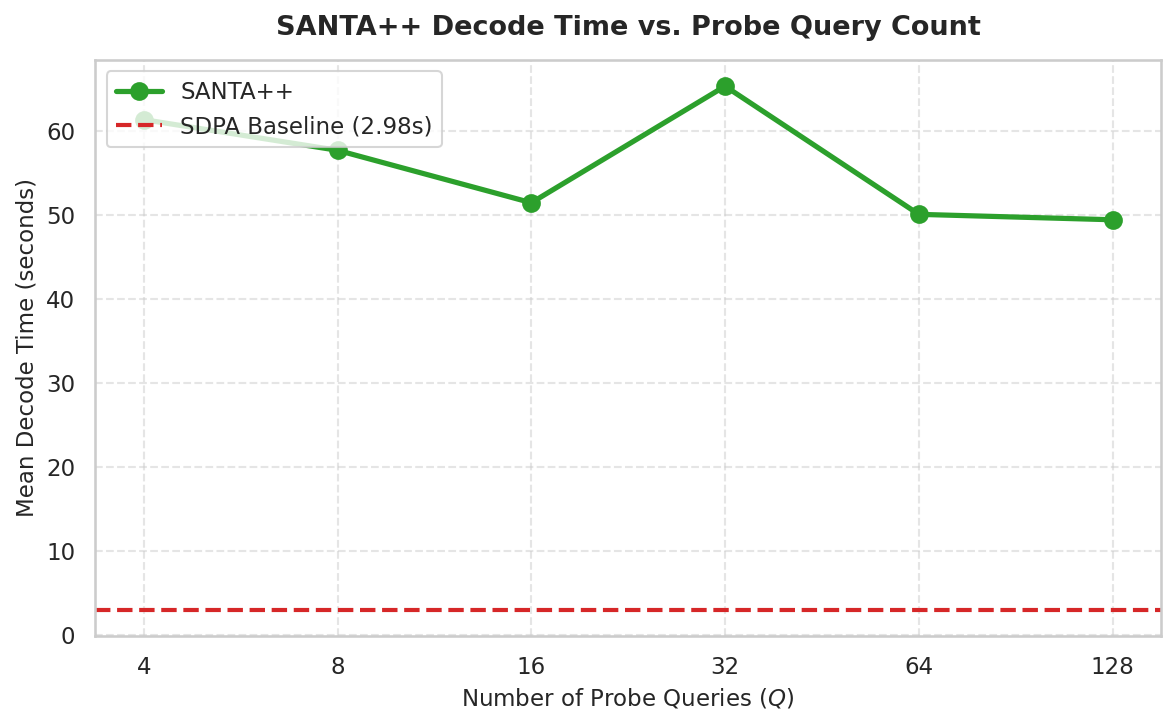

In [4]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 150

# ==============================================================================
# 1. Parse Results Directory for Decode Times
# ==============================================================================
RESULTS_DIR = Path("./full-probe-count-sweep")

records = []

for run_dir in sorted(RESULTS_DIR.glob("probe_q_*")):
    if not run_dir.is_dir():
        continue
    
    try:
        probe_q = int(run_dir.name.split("_")[-1])
    except ValueError:
        continue

    summary_file = run_dir / "summary.json"
    
    if summary_file.exists():
        try:
            with open(summary_file, "r", encoding="utf-8") as f:
                summary_data = json.load(f)
            
            backends_dict = summary_data.get("backends", summary_data)
            
            for backend, backend_info in backends_dict.items():
                if not isinstance(backend_info, dict):
                    continue
                
                tasks_dict = backend_info.get("tasks", {})
                for task_name, task_metrics in tasks_dict.items():
                    if task_name in ["__selected_task_mean__", "aggregate"]:
                        continue
                    
                    if isinstance(task_metrics, dict) and "mean_decode_seconds" in task_metrics:
                        records.append({
                            "probe_queries": probe_q,
                            "backend": backend,
                            "task": task_name,
                            "decode_seconds": float(task_metrics["mean_decode_seconds"])
                        })
        except Exception as e:
            print(f"Error parsing {summary_file}: {e}")

df = pd.DataFrame(records)

if df.empty:
    raise RuntimeError(f"No records found in {RESULTS_DIR.resolve()}. Check directory structure.")

# ==============================================================================
# 2. Compute Aggregated Decode Metrics
# ==============================================================================
# Extract baseline SDPA decode time (mean across tasks)
sdpa_df = df[df["backend"] == "sdpa"]
sdpa_mean_decode = sdpa_df["decode_seconds"].mean() if not sdpa_df.empty else None

# Aggregate SANTA++ decode time by probe query count
santapp_df = df[df["backend"] == "santapp"]
summary_df = santapp_df.groupby("probe_queries")["decode_seconds"].agg(["mean", "std"]).reset_index()
summary_df.rename(columns={"mean": "avg_decode_seconds"}, inplace=True)

print("=== SANTA++ Mean Decode Time by Probe Query Count ===")
print(summary_df.to_string(index=False))

if sdpa_mean_decode is not None:
    print(f"\nBaseline SDPA Overall Mean Decode Time: {sdpa_mean_decode:.3f} seconds\n")

# ==============================================================================
# 3. Plot: Decode Time vs. Probe Query Count
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 5))

# Plot SANTA++ curve
ax.plot(
    summary_df["probe_queries"],
    summary_df["avg_decode_seconds"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#2ca02c",
    label="SANTA++"
)

# Plot Baseline SDPA line if available
if sdpa_mean_decode is not None:
    ax.axhline(
        y=sdpa_mean_decode,
        color="#d62728",
        linestyle="--",
        linewidth=2,
        label=f"SDPA Baseline ({sdpa_mean_decode:.2f}s)"
    )

ax.set_xscale("log", base=2)
ax.set_xticks(summary_df["probe_queries"])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax.set_title("SANTA++ Decode Time vs. Probe Query Count", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Number of Probe Queries ($Q$)", fontsize=11)
ax.set_ylabel("Mean Decode Time (seconds)", fontsize=11)
ax.legend(frameon=True, loc="upper left")
ax.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("probe_count_vs_decode_time.png", dpi=300)
plt.show()

=== SANTA++ Mean Total Execution Time by Probe Query Count ===
 probe_queries  avg_total_seconds       std
            16          53.938208 22.339388
            32          53.120876 19.601343
            64          56.197258 22.855942
           128          60.077036 21.977971
           256          70.084254 21.324239

Baseline SDPA Overall Mean Total Time: 3.262 seconds



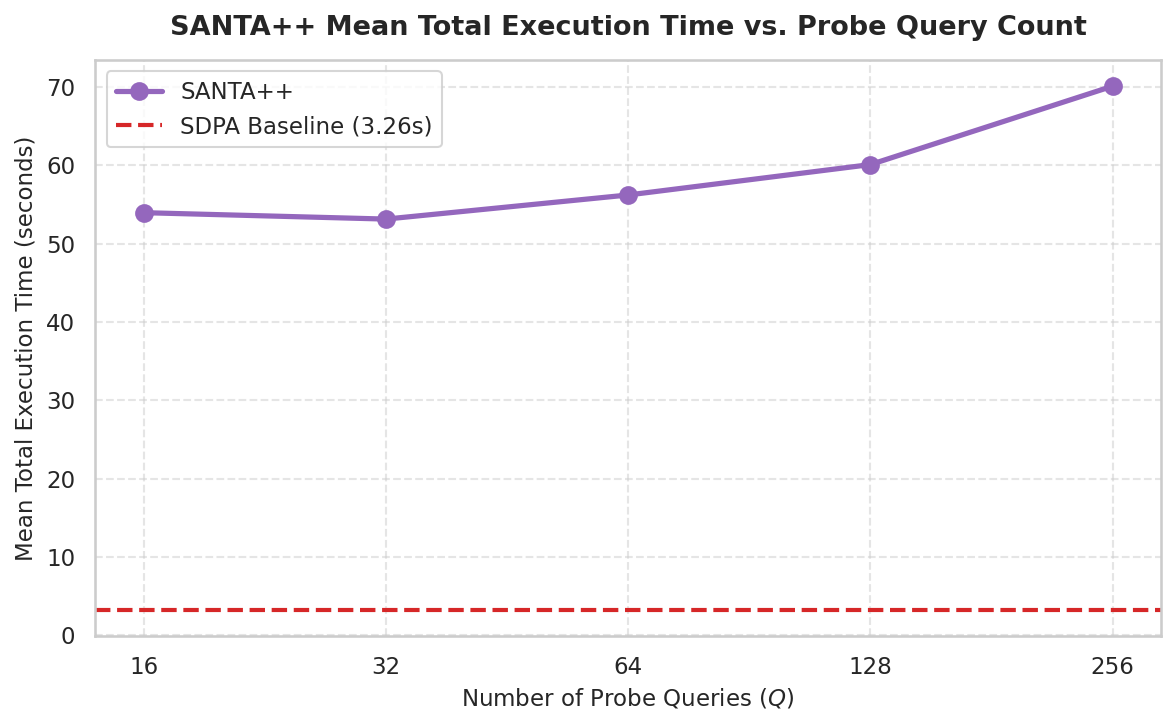

In [9]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 150

# ==============================================================================
# 1. Parse Results Directory for Total Execution Times
# ==============================================================================
RESULTS_DIR = Path("./full-probe-count-resweep")

records = []

for run_dir in sorted(RESULTS_DIR.glob("probe_q_*")):
    if not run_dir.is_dir():
        continue
    
    try:
        probe_q = int(run_dir.name.split("_")[-1])
    except ValueError:
        continue

    summary_file = run_dir / "summary.json"
    
    if summary_file.exists():
        try:
            with open(summary_file, "r", encoding="utf-8") as f:
                summary_data = json.load(f)
            
            backends_dict = summary_data.get("backends", summary_data)
            
            for backend, backend_info in backends_dict.items():
                if not isinstance(backend_info, dict):
                    continue
                
                tasks_dict = backend_info.get("tasks", {})
                for task_name, task_metrics in tasks_dict.items():
                    if task_name in ["__selected_task_mean__", "aggregate"]:
                        continue
                    
                    if isinstance(task_metrics, dict) and "mean_total_seconds" in task_metrics:
                        records.append({
                            "probe_queries": probe_q,
                            "backend": backend,
                            "task": task_name,
                            "total_seconds": float(task_metrics["mean_total_seconds"])
                        })
        except Exception as e:
            print(f"Error parsing {summary_file}: {e}")

df = pd.DataFrame(records)

if df.empty:
    raise RuntimeError(f"No records found in {RESULTS_DIR.resolve()}. Check directory structure.")

# ==============================================================================
# 2. Compute Aggregated Total Execution Time Metrics
# ==============================================================================
# Extract baseline SDPA total execution time (mean across tasks)
sdpa_df = df[df["backend"] == "sdpa"]
sdpa_mean_total = sdpa_df["total_seconds"].mean() if not sdpa_df.empty else None

# Aggregate SANTA++ total execution time by probe query count
santapp_df = df[df["backend"] == "santapp"]
summary_df = santapp_df.groupby("probe_queries")["total_seconds"].agg(["mean", "std"]).reset_index()
summary_df.rename(columns={"mean": "avg_total_seconds"}, inplace=True)

print("=== SANTA++ Mean Total Execution Time by Probe Query Count ===")
print(summary_df.to_string(index=False))

if sdpa_mean_total is not None:
    print(f"\nBaseline SDPA Overall Mean Total Time: {sdpa_mean_total:.3f} seconds\n")

# ==============================================================================
# 3. Plot: Mean Total Execution Time vs. Probe Query Count
# ==============================================================================
fig, ax = plt.subplots(figsize=(8, 5))

# Plot SANTA++ curve
ax.plot(
    summary_df["probe_queries"],
    summary_df["avg_total_seconds"],
    marker="o",
    linewidth=2.5,
    markersize=8,
    color="#9467bd",
    label="SANTA++"
)

# Plot Baseline SDPA line if available
if sdpa_mean_total is not None:
    ax.axhline(
        y=sdpa_mean_total,
        color="#d62728",
        linestyle="--",
        linewidth=2,
        label=f"SDPA Baseline ({sdpa_mean_total:.2f}s)"
    )

ax.set_xscale("log", base=2)
ax.set_xticks(summary_df["probe_queries"])
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax.set_title("SANTA++ Mean Total Execution Time vs. Probe Query Count", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Number of Probe Queries ($Q$)", fontsize=11)
ax.set_ylabel("Mean Total Execution Time (seconds)", fontsize=11)
ax.legend(frameon=True, loc="upper left")
ax.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("probe_count_vs_total_time_v3.png", dpi=300)
plt.show()

Successfully loaded 208 total task records.

=== SANTA++ Accuracy Summary ===
                 sweep  probe_queries  avg_accuracy       std
SANTA++ (2048 samples)             16     69.217692 31.892244
SANTA++ (2048 samples)             32     75.243846 26.682182
SANTA++ (2048 samples)             64     70.486923 29.823099
SANTA++ (2048 samples)            128     78.410000 25.248141
SANTA++ (2048 samples)            256     76.128462 24.017067
  SANTA++ (Full Sweep)              4     29.230769 26.930168
  SANTA++ (Full Sweep)              8     34.346154 26.103468
  SANTA++ (Full Sweep)             16     41.153846 29.742916
  SANTA++ (Full Sweep)             32     45.333077 29.182824
  SANTA++ (Full Sweep)             64     45.513077 28.393906
  SANTA++ (Full Sweep)            128     51.038462 30.799392
  SANTA++ (Full Sweep)            256     48.038462 28.542703
  SANTA++ (Full Sweep)            512     45.205385 29.978521

Baseline SDPA Overall Accuracy: 87.99%



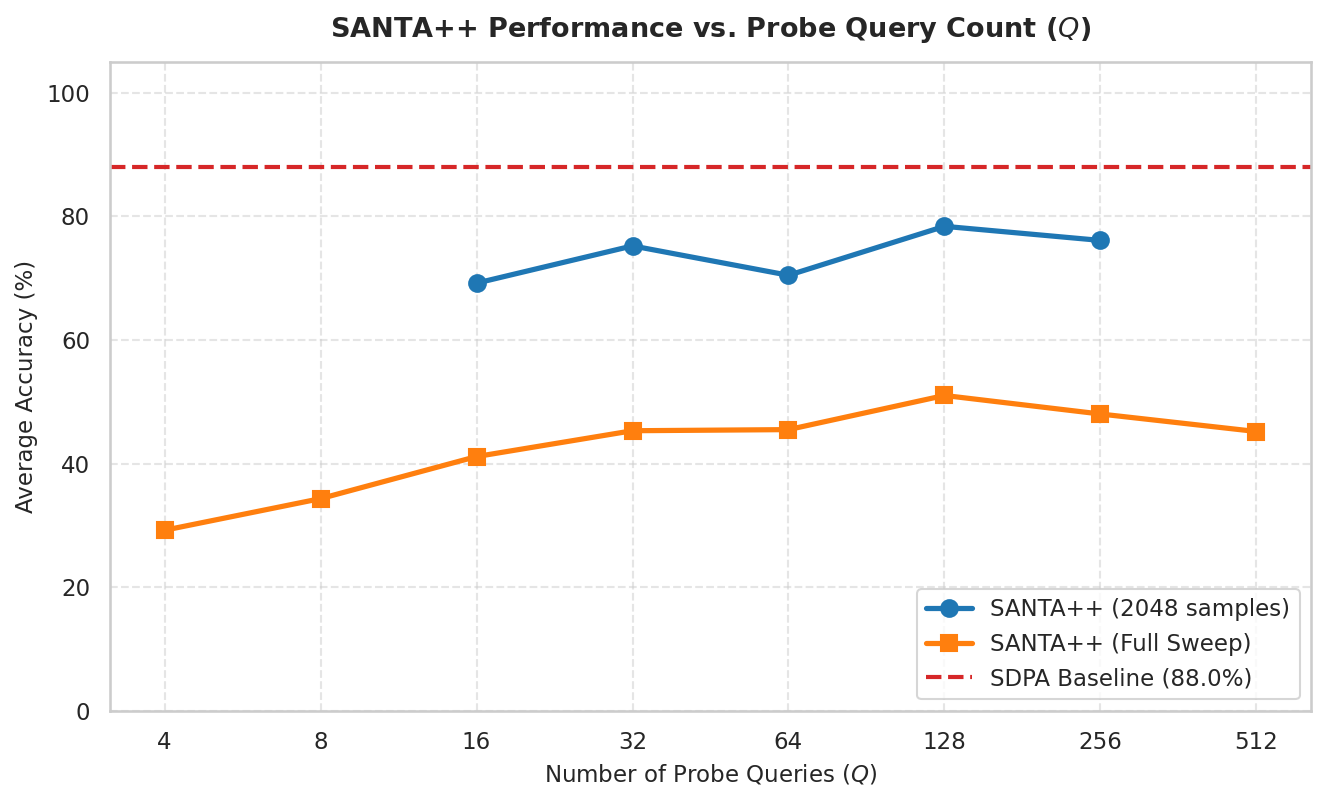

In [10]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Set plot styling
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["font.sans-serif"] = "DejaVu Sans"
plt.rcParams["figure.dpi"] = 150

# ==============================================================================
# 1. Helper Function to Parse Directories
# ==============================================================================
def parse_sweep_directory(results_dir: Path, dataset_label: str):
    records = []
    if not results_dir.exists():
        print(f"Warning: Directory {results_dir} does not exist.")
        return records

    for run_dir in sorted(results_dir.glob("probe_q_*")):
        if not run_dir.is_dir():
            continue
        
        # Extract Q from probe_q_X folder name
        try:
            probe_q = int(run_dir.name.split("_")[-1])
        except ValueError:
            continue

        summary_file = run_dir / "summary.json"
        
        if summary_file.exists():
            try:
                with open(summary_file, "r", encoding="utf-8") as f:
                    summary_data = json.load(f)
                
                backends_dict = summary_data.get("backends", summary_data)
                
                for backend, backend_info in backends_dict.items():
                    if not isinstance(backend_info, dict):
                        continue
                    
                    tasks_dict = backend_info.get("tasks", {})
                    for task_name, task_metrics in tasks_dict.items():
                        if task_name in ["__selected_task_mean__", "aggregate"]:
                            continue
                        
                        if isinstance(task_metrics, dict) and "score" in task_metrics:
                            records.append({
                                "probe_queries": probe_q,
                                "backend": backend,
                                "task": task_name,
                                "accuracy": float(task_metrics["score"]),
                                "sweep": dataset_label
                            })
            except Exception as e:
                print(f"Error parsing {summary_file}: {e}")
    return records

# ==============================================================================
# 2. Parse Both Sweep Directories
# ==============================================================================
DIR_2048 = Path("./full-probe-count-resweep")
DIR_SWEEP = Path("./full-probe-count-sweep")

records_2048 = parse_sweep_directory(DIR_2048, "SANTA++ (2048 samples)")
records_sweep = parse_sweep_directory(DIR_SWEEP, "SANTA++ (Full Sweep)")

all_records = records_2048 + records_sweep
df = pd.DataFrame(all_records)

print(f"Successfully loaded {len(df)} total task records.\n")

if df.empty:
    raise RuntimeError("No records parsed. Check your directory paths and JSON structure.")

# ==============================================================================
# 3. Compute Aggregated Metrics
# ==============================================================================
# Baseline SDPA performance
sdpa_df = df[df["backend"] == "sdpa"]
sdpa_overall_acc = sdpa_df["accuracy"].mean() if not sdpa_df.empty else None

# Aggregate SANTA++ accuracy grouped by sweep label and probe_queries
santapp_df = df[df["backend"] == "santapp"]
summary_df = (
    santapp_df.groupby(["sweep", "probe_queries"])["accuracy"]
    .agg(["mean", "std"])
    .reset_index()
    .rename(columns={"mean": "avg_accuracy"})
)

print("=== SANTA++ Accuracy Summary ===")
print(summary_df.to_string(index=False))

if sdpa_overall_acc is not None:
    print(f"\nBaseline SDPA Overall Accuracy: {sdpa_overall_acc:.2f}%\n")

# ==============================================================================
# 4. Plot Overall Accuracy vs. Probe Query Count (Comparison)
# ==============================================================================
fig, ax = plt.subplots(figsize=(9, 5.5))

# Palette for the two SANTA++ series
colors = {
    "SANTA++ (2048 samples)": "#1f77b4",  # Blue
    "SANTA++ (Full Sweep)": "#ff7f0e"     # Orange
}

markers = {
    "SANTA++ (2048 samples)": "o",
    "SANTA++ (Full Sweep)": "s"
}

# Plot each sweep run series
for sweep_label, group in summary_df.groupby("sweep"):
    ax.plot(
        group["probe_queries"],
        group["avg_accuracy"],
        marker=markers.get(sweep_label, "o"),
        linewidth=2.5,
        markersize=8,
        color=colors.get(sweep_label, None),
        label=sweep_label
    )

# Plot SDPA Baseline
if sdpa_overall_acc is not None:
    ax.axhline(
        y=sdpa_overall_acc,
        color="#d62728",
        linestyle="--",
        linewidth=2,
        label=f"SDPA Baseline ({sdpa_overall_acc:.1f}%)"
    )

ax.set_xscale("log", base=2)

# Set x-ticks across all unique probe query counts present in the data
unique_probes = sorted(summary_df["probe_queries"].unique())
ax.set_xticks(unique_probes)
ax.get_xaxis().set_major_formatter(plt.ScalarFormatter())

ax.set_title("SANTA++ Performance vs. Probe Query Count ($Q$)", fontsize=13, fontweight="bold", pad=12)
ax.set_xlabel("Number of Probe Queries ($Q$)", fontsize=11)
ax.set_ylabel("Average Accuracy (%)", fontsize=11)
ax.set_ylim(0, 105)
ax.legend(frameon=True, loc="lower right")
ax.grid(True, which="both", linestyle="--", alpha=0.5)

plt.tight_layout()
plt.savefig("probe_count_comparison.png", dpi=300)
plt.show()